In [1]:
# ==========================================
# Standard Libraries
# ==========================================
import os
import time
import random
import warnings
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")

# ==========================================
# PyTorch
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

# Mixed Precision
from torch.cuda.amp import GradScaler, autocast

# Progress Bar
from tqdm.auto import tqdm

# ==========================================
# Metrics
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

# ==========================================
# Random Seed
# ==========================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# ==========================================
# Device
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("="*60)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Device : cuda
GPU : Tesla P100-PCIE-16GB


In [2]:
# ==========================================
# Dataset Paths
# ==========================================
TRAIN_DIR = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train"
TEST_DIR = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test"

# ==========================================
# Hyperparameters
# ==========================================
IMAGE_SIZE = 224

BATCH_SIZE = 64

EPOCHS_STAGE1 = 8

EPOCHS_STAGE2 = 12

LEARNING_RATE_STAGE1 = 1e-3

LEARNING_RATE_STAGE2 = 1e-5

NUM_WORKERS = 2

PATIENCE = 5

MODEL_NAME = "ResNet50"

NUM_CLASSES = 1

In [3]:
RESULTS_DIR = "Results"

folders = [
    "Models",
    "Plots",
    "Metrics",
    "Predictions",
    "GradCAM",
    "Misclassified"
]

os.makedirs(RESULTS_DIR, exist_ok=True)

for folder in folders:
    os.makedirs(os.path.join(RESULTS_DIR, folder), exist_ok=True)

print("Output folders created.")

Output folders created.


In [4]:
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1),
        scale=(0.9,1.1)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [5]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Classes :", train_dataset.classes)

print("Training Images :", len(train_dataset))

print("Testing Images :", len(test_dataset))

Classes : ['FAKE', 'REAL']
Training Images : 100000
Testing Images : 20000


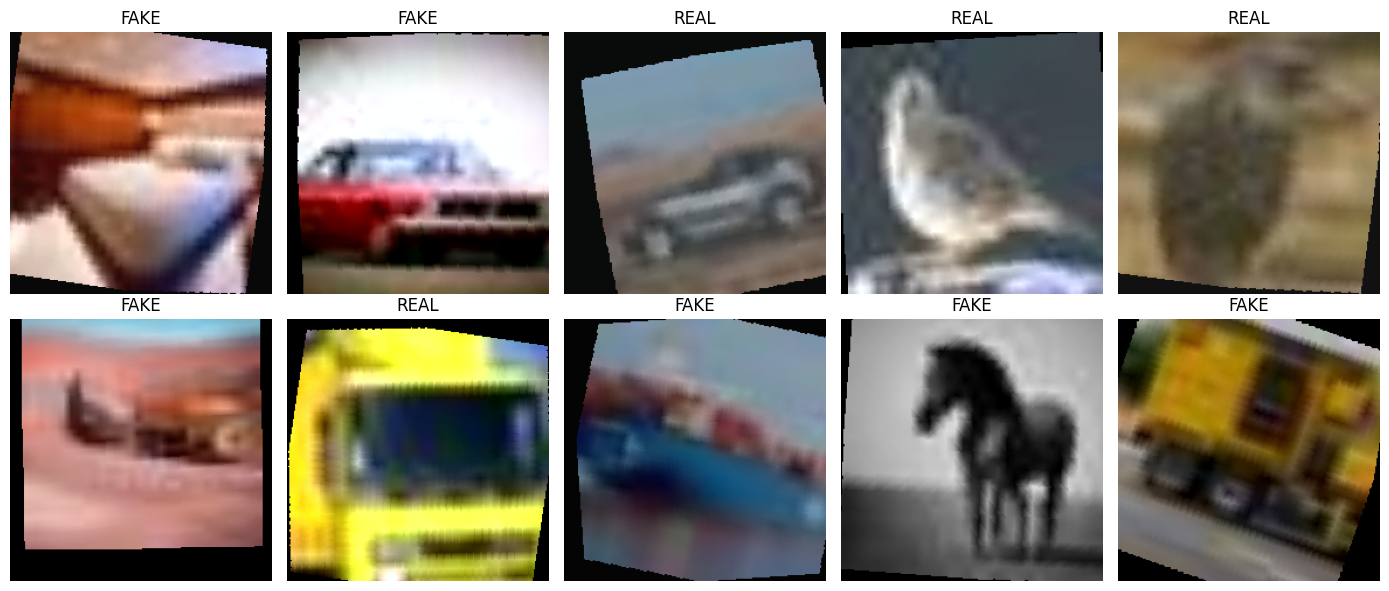

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,5, figsize=(14,6))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225])

    img += np.array([0.485,0.456,0.406])

    img = np.clip(img,0,1)

    ax.imshow(img)

    ax.set_title(train_dataset.classes[labels[i]])

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Plots",
        "dataset_samples.png"
    ),
    dpi=300
)

plt.show()

In [7]:
from collections import Counter

train_labels = [label for _,label in train_dataset.samples]

test_labels = [label for _,label in test_dataset.samples]

train_counts = Counter(train_labels)

test_counts = Counter(test_labels)

df = pd.DataFrame({

    "Class":train_dataset.classes,

    "Train":[train_counts[i] for i in range(len(train_dataset.classes))],

    "Test":[test_counts[i] for i in range(len(test_dataset.classes))]
})

display(df)

df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "Metrics",
        "dataset_statistics.csv"
    ),
    index=False
)

,Class,Train,Test
0,FAKE,50000,10000
1,REAL,50000,10000


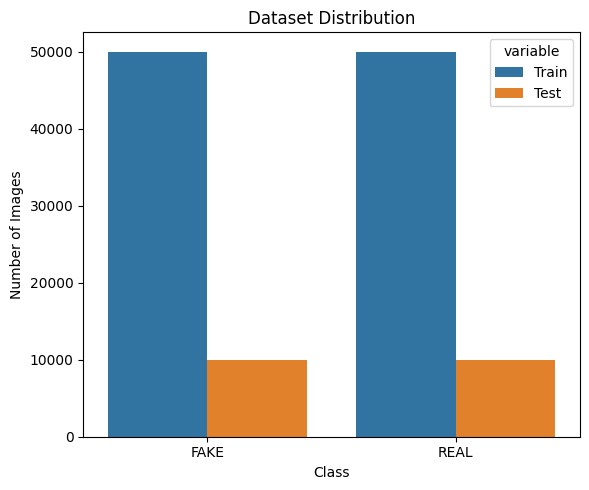

In [8]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df.melt(id_vars="Class"),
    x="Class",
    y="value",
    hue="variable"
)

plt.ylabel("Number of Images")

plt.xlabel("Class")

plt.title("Dataset Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Plots",
        "dataset_distribution.png"
    ),
    dpi=300
)

plt.show()

In [9]:
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 270MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [10]:
# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(num_features,512),

    nn.BatchNorm1d(512),

    nn.ReLU(inplace=True),

    nn.Dropout(0.5),

    nn.Linear(512,128),

    nn.ReLU(inplace=True),

    nn.Dropout(0.3),

    nn.Linear(128,1)

)

model = model.to(device)

print(model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=512, out_features=128, bias=True)
  (5): ReLU(inplace=True)
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=128, out_features=1, bias=True)
)


In [11]:
# ==========================================
# Loss Function
# ==========================================
criterion = nn.BCEWithLogitsLoss()

# ==========================================
# Optimizer
# (Only classifier parameters are trainable)
# ==========================================
optimizer = optim.AdamW(

    model.fc.parameters(),

    lr=LEARNING_RATE_STAGE1,

    weight_decay=1e-4

)

# ==========================================
# Cosine Scheduler
# ==========================================
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS_STAGE1,

    eta_min=1e-6

)

# ==========================================
# Mixed Precision
# ==========================================
scaler = GradScaler()

print("Optimizer Ready")

Optimizer Ready


In [12]:
history = {

    "epoch": [],

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": [],

    "precision": [],

    "recall": [],

    "f1": [],

    "learning_rate": [],

    "epoch_time": []

}

best_loss = float("inf")

early_counter = 0

In [13]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    y_true = []

    y_pred = []

    progress = tqdm(

        loader,

        leave=False,

        colour="green",

        desc="Training"

    )

    for images, labels in progress:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(predictions.cpu().numpy())

        progress.set_postfix({

            "Loss":f"{loss.item():.4f}",

            "Acc":f"{accuracy_score(y_true,y_pred):.4f}",

            "LR":f"{optimizer.param_groups[0]['lr']:.2e}"

        })

    return (

        running_loss/len(loader),

        accuracy_score(y_true,y_pred)

    )

In [14]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    y_true = []

    y_pred = []

    y_prob = []

    progress = tqdm(

        loader,

        leave=False,

        colour="blue",

        desc="Validation"

    )

    with torch.no_grad():

        for images, labels in progress:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs>0.5).float()

            y_true.extend(labels.cpu().numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

            progress.set_postfix({

                "Loss":f"{loss.item():.4f}"

            })

    return (

        running_loss/len(loader),

        accuracy_score(y_true,y_pred),

        precision_score(y_true,y_pred),

        recall_score(y_true,y_pred),

        f1_score(y_true,y_pred),

        np.array(y_true),

        np.array(y_pred),

        np.array(y_prob)

    )

In [15]:
print("="*70)
print("STAGE 1 : Training Classifier")
print("="*70)

for epoch in range(EPOCHS_STAGE1):

    start = time.time()

    train_loss, train_acc = train_one_epoch(

        model,

        train_loader

    )

    (

        val_loss,

        val_acc,

        precision,

        recall,

        f1,

        y_true,

        y_pred,

        y_prob

    ) = validate(

        model,

        test_loader

    )

    scheduler.step()

    elapsed = time.time()-start

    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch+1)

    history["train_loss"].append(train_loss)

    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)

    history["val_acc"].append(val_acc)

    history["precision"].append(precision)

    history["recall"].append(recall)

    history["f1"].append(f1)

    history["learning_rate"].append(lr)

    history["epoch_time"].append(elapsed)

    print("\n"+"="*70)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1}")

    print(f"Train Loss      : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy  : {train_acc:.4f}")

    print(f"Validation Acc  : {val_acc:.4f}")

    print(f"Precision       : {precision:.4f}")

    print(f"Recall          : {recall:.4f}")

    print(f"F1 Score        : {f1:.4f}")

    print(f"Learning Rate   : {lr:.2e}")

    print(f"Epoch Time      : {elapsed:.2f} sec")

    if val_loss < best_loss:

        best_loss = val_loss

        early_counter = 0

        torch.save(

            model.state_dict(),

            os.path.join(

                RESULTS_DIR,

                "Models",

                "stage1_best_model.pth"

            )

        )

        print("✅ Best model saved.")

    else:

        early_counter += 1

        print(f"No Improvement ({early_counter}/{PATIENCE})")

        if early_counter >= PATIENCE:

            print("Early Stopping Triggered")

            break

STAGE 1 : Training Classifier


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 1/8
Train Loss      : 0.3323
Validation Loss : 0.3548
Train Accuracy  : 0.8550
Validation Acc  : 0.8467
Precision       : 0.9246
Recall          : 0.7550
F1 Score        : 0.8312
Learning Rate   : 9.62e-04
Epoch Time      : 829.68 sec
✅ Best model saved.


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 7/8
Train Loss      : 0.2538
Validation Loss : 0.2748
Train Accuracy  : 0.8945
Validation Acc  : 0.8831
Precision       : 0.8730
Recall          : 0.8968
F1 Score        : 0.8847
Learning Rate   : 3.90e-05
Epoch Time      : 525.07 sec
No Improvement (2/5)


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 8/8
Train Loss      : 0.2484
Validation Loss : 0.2736
Train Accuracy  : 0.8969
Validation Acc  : 0.8846
Precision       : 0.8964
Recall          : 0.8697
F1 Score        : 0.8829
Learning Rate   : 1.00e-06
Epoch Time      : 593.93 sec
No Improvement (3/5)


In [16]:
history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        RESULTS_DIR,

        "Metrics",

        "stage1_history.csv"

    ),

    index=False

)

history_df.head()

,epoch,train_loss,val_loss,train_acc,val_acc,precision,recall,f1,learning_rate,epoch_time
0,1,0.332309,0.354810,0.85501,0.84670,0.924565,0.7550,0.831223,0.000962,829.675234
1,2,0.296095,0.296602,0.87619,0.87505,0.888613,0.8576,0.872831,0.000854,528.101468
2,3,0.284675,0.313018,0.88056,0.86505,0.858208,0.8746,0.866327,0.000692,530.101901
3,4,0.276610,0.310261,0.88467,0.86550,0.931319,0.7892,0.854390,0.000501,546.667467
4,5,0.267417,0.269422,0.88897,0.88595,0.879835,0.8940,0.886861,0.000309,535.185777


In [17]:
model.load_state_dict(

    torch.load(

        os.path.join(

            RESULTS_DIR,

            "Models",

            "stage1_best_model.pth"

        )

    )

)

print("Best Stage 1 Model Loaded")

Best Stage 1 Model Loaded


In [18]:
# ==========================================
# Load Best Stage 1 Model
# ==========================================
model.load_state_dict(
    torch.load(
        os.path.join(
            RESULTS_DIR,
            "Models",
            "stage1_best_model.pth"
        )
    )
)

print("✅ Stage 1 Model Loaded")

✅ Stage 1 Model Loaded


In [19]:
# ==========================================
# Freeze Everything
# ==========================================
for param in model.parameters():
    param.requires_grad = False

# ==========================================
# Unfreeze Layer4
# ==========================================
for param in model.layer4.parameters():
    param.requires_grad = True

# ==========================================
# Unfreeze Classifier
# ==========================================
for param in model.fc.parameters():
    param.requires_grad = True

print("Layer4 and FC unfrozen.")

Layer4 and FC unfrozen.


In [20]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

print(f"Trainable % : {100*trainable/total:.2f}%")

Trainable Parameters : 16,080,641
Total Parameters     : 24,623,937
Trainable % : 65.30%


In [21]:
optimizer = optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=LEARNING_RATE_STAGE2,

    weight_decay=1e-4

)

In [22]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(

    optimizer,

    T_0=4,

    T_mult=2,

    eta_min=1e-7

)

print("Cosine Warm Restarts Enabled")

Cosine Warm Restarts Enabled


In [23]:
stage2_history = {

    "epoch":[],

    "train_loss":[],

    "val_loss":[],

    "train_acc":[],

    "val_acc":[],

    "precision":[],

    "recall":[],

    "f1":[],

    "learning_rate":[],

    "epoch_time":[]

}

In [24]:
best_loss = float("inf")

early_counter = 0

print("Fine-tuning initialized.")

Fine-tuning initialized.


In [25]:
print("="*70)
print("STAGE 2 : Fine-Tuning Layer4")
print("="*70)

for epoch in range(EPOCHS_STAGE2):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    (
        val_loss,
        val_acc,
        precision,
        recall,
        f1,
        y_true,
        y_pred,
        y_prob
    ) = validate(
        model,
        test_loader
    )

    scheduler.step(epoch + val_loss)

    elapsed = time.time() - start

    lr = optimizer.param_groups[0]["lr"]

    stage2_history["epoch"].append(epoch+1)
    stage2_history["train_loss"].append(train_loss)
    stage2_history["val_loss"].append(val_loss)
    stage2_history["train_acc"].append(train_acc)
    stage2_history["val_acc"].append(val_acc)
    stage2_history["precision"].append(precision)
    stage2_history["recall"].append(recall)
    stage2_history["f1"].append(f1)
    stage2_history["learning_rate"].append(lr)
    stage2_history["epoch_time"].append(elapsed)

    print("\n"+"="*70)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE2}")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Validation Acc  : {val_acc:.4f}")

    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1 Score        : {f1:.4f}")

    print(f"Learning Rate   : {lr:.2e}")
    print(f"Epoch Time      : {elapsed:.2f} sec")

    if val_loss < best_loss:

        best_loss = val_loss

        early_counter = 0

        torch.save(

            model.state_dict(),

            os.path.join(

                RESULTS_DIR,

                "Models",

                "best_resnet50_finetuned.pth"

            )

        )

        print("✅ New Best Model Saved")

    else:

        early_counter += 1

        print(f"No Improvement ({early_counter}/{PATIENCE})")

        if early_counter >= PATIENCE:

            print("🛑 Early Stopping")

            break

STAGE 2 : Fine-Tuning Layer4


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 1/12
Train Loss      : 0.2329
Validation Loss : 0.2259
Train Accuracy  : 0.9038
Validation Acc  : 0.9074
Precision       : 0.9097
Recall          : 0.9046
F1 Score        : 0.9071
Learning Rate   : 9.92e-06
Epoch Time      : 660.35 sec
✅ New Best Model Saved


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 11/12
Train Loss      : 0.1350
Validation Loss : 0.1567
Train Accuracy  : 0.9478
Validation Acc  : 0.9377
Precision       : 0.9624
Recall          : 0.9111
F1 Score        : 0.9360
Learning Rate   : 1.34e-06
Epoch Time      : 570.83 sec
✅ New Best Model Saved


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 12/12
Train Loss      : 0.1319
Validation Loss : 0.1504
Train Accuracy  : 0.9493
Validation Acc  : 0.9403
Precision       : 0.9620
Recall          : 0.9168
F1 Score        : 0.9389
Learning Rate   : 3.73e-07
Epoch Time      : 577.70 sec
✅ New Best Model Saved


In [26]:
history2 = pd.DataFrame(stage2_history)

history2.to_csv(

    os.path.join(

        RESULTS_DIR,

        "Metrics",

        "stage2_history.csv"

    ),

    index=False

)

history2.head()

,epoch,train_loss,val_loss,train_acc,val_acc,precision,recall,f1,learning_rate,epoch_time
0,1,0.232873,0.225906,0.90377,0.90740,0.909694,0.9046,0.907140,0.000010,660.349642
1,2,0.199547,0.205123,0.92035,0.91770,0.940705,0.8916,0.915494,0.000008,565.179535
2,3,0.184084,0.188446,0.92588,0.92410,0.940212,0.9058,0.922685,0.000004,564.726100
3,4,0.173844,0.187564,0.93082,0.92465,0.946953,0.8997,0.922722,0.000001,568.644063
4,5,0.170444,0.193721,0.93242,0.92075,0.948226,0.8901,0.918244,0.000010,569.776948


In [27]:
model.load_state_dict(

    torch.load(

        os.path.join(

            RESULTS_DIR,

            "Models",

            "best_resnet50_finetuned.pth"

        )

    )

)

model.eval()

print("✅ Final Model Ready")

✅ Final Model Ready


In [28]:
start = time.time()

with torch.no_grad():

    dummy = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    ).to(device)

    _ = model(dummy)

elapsed = (time.time()-start)*1000

print(f"Inference Time : {elapsed:.2f} ms/image")

Inference Time : 458.72 ms/image


In [29]:
# ==========================================
# Metrics
# ==========================================

accuracy = accuracy_score(y_true,y_pred)

precision = precision_score(y_true,y_pred)

recall = recall_score(y_true,y_pred)

f1 = f1_score(y_true,y_pred)

balanced_acc = balanced_accuracy_score(y_true,y_pred)

mcc = matthews_corrcoef(y_true,y_pred)

kappa = cohen_kappa_score(y_true,y_pred)

cm = confusion_matrix(y_true,y_pred)

TN,FP,FN,TP = cm.ravel()

specificity = TN/(TN+FP)

sensitivity = recall

roc_auc = auc(
    *roc_curve(y_true,y_prob)[:2]
)

pr_auc = average_precision_score(
    y_true,
    y_prob
)

metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Balanced Accuracy",

        "Specificity",

        "Sensitivity",

        "ROC AUC",

        "PR AUC",

        "Matthews CC",

        "Cohen Kappa"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        balanced_acc,

        specificity,

        sensitivity,

        roc_auc,

        pr_auc,

        mcc,

        kappa

    ]

})

display(metrics)

,Metric,Value
0,Accuracy,0.940300
1,Precision,0.962015
2,Recall,0.916800
3,F1 Score,0.938863
4,Balanced Accuracy,0.940300
5,Specificity,0.963800
6,Sensitivity,0.916800
7,ROC AUC,0.987602
8,PR AUC,0.988180
9,Matthews CC,0.881574


In [30]:
metrics.to_csv(

    os.path.join(

        RESULTS_DIR,

        "Metrics",

        "evaluation_metrics.csv"

    ),

    index=False

)

print(metrics)

               Metric     Value
0            Accuracy  0.940300
1           Precision  0.962015
2              Recall  0.916800
3            F1 Score  0.938863
4   Balanced Accuracy  0.940300
5         Specificity  0.963800
6         Sensitivity  0.916800
7             ROC AUC  0.987602
8              PR AUC  0.988180
9         Matthews CC  0.881574
10        Cohen Kappa  0.880600


In [31]:
report = classification_report(

    y_true,

    y_pred,

    target_names=train_dataset.classes,

    digits=4

)

print(report)

with open(

    os.path.join(

        RESULTS_DIR,

        "Metrics",

        "classification_report.txt"

    ),

    "w"

) as f:

    f.write(report)

              precision    recall  f1-score   support

        FAKE     0.9205    0.9638    0.9417     10000
        REAL     0.9620    0.9168    0.9389     10000

    accuracy                         0.9403     20000
   macro avg     0.9413    0.9403    0.9403     20000
weighted avg     0.9413    0.9403    0.9403     20000



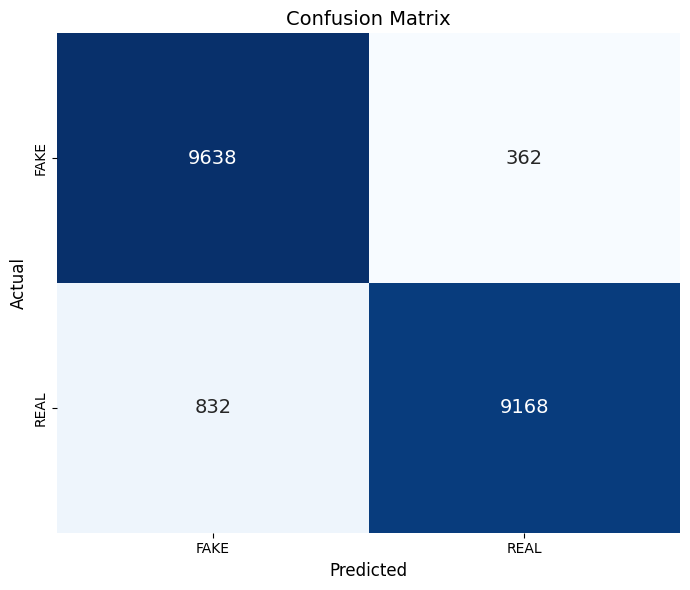

In [32]:
plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d",

    xticklabels=train_dataset.classes,

    yticklabels=train_dataset.classes,

    cbar=False,

    annot_kws={"size":14}

)

plt.xlabel("Predicted",fontsize=12)

plt.ylabel("Actual",fontsize=12)

plt.title("Confusion Matrix",fontsize=14)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "confusion_matrix.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

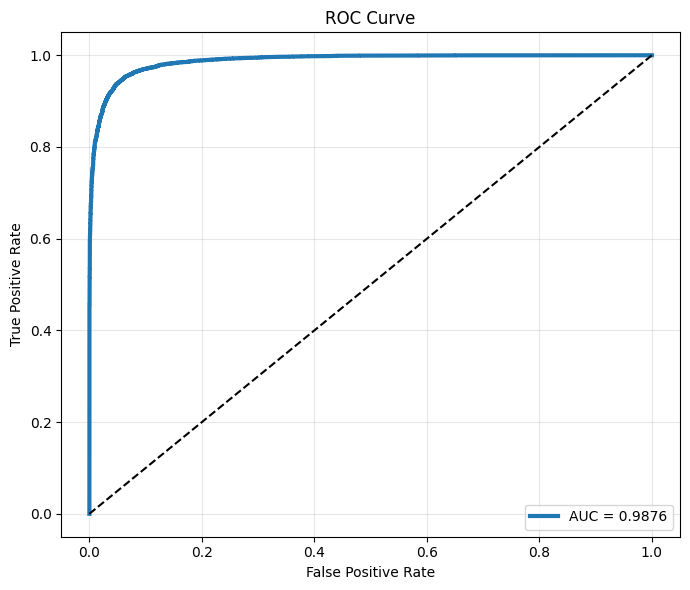

In [33]:
fpr,tpr,_ = roc_curve(

    y_true,

    y_prob

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    linewidth=3,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "roc_curve.png"

    ),

    dpi=300

)

plt.show()

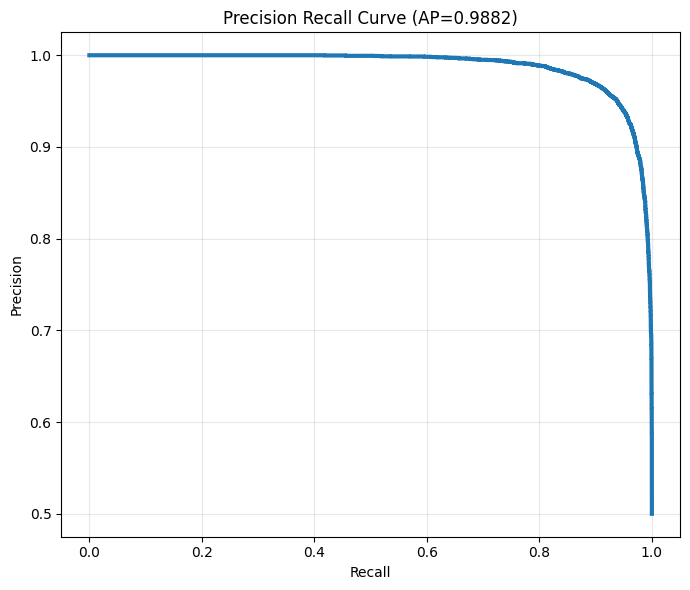

In [34]:
precision_curve, recall_curve, _ = precision_recall_curve(

    y_true,

    y_prob

)

plt.figure(figsize=(7,6))

plt.plot(

    recall_curve,

    precision_curve,

    linewidth=3

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(f"Precision Recall Curve (AP={pr_auc:.4f})")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "precision_recall_curve.png"

    ),

    dpi=300

)

plt.show()

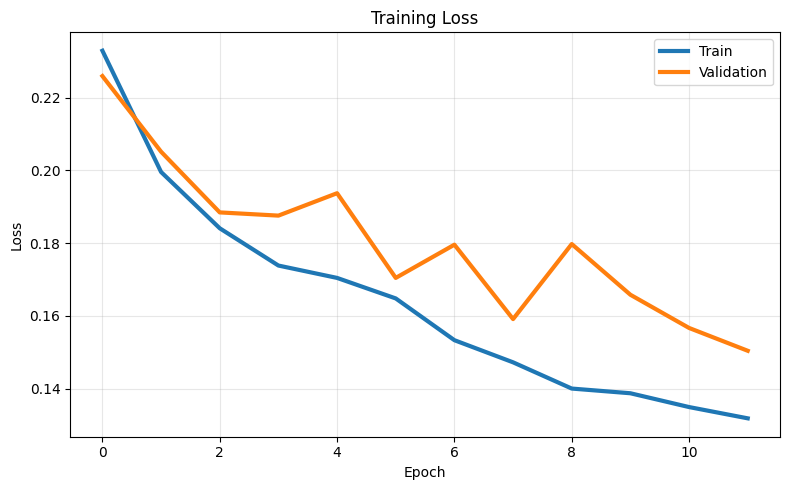

In [35]:
plt.figure(figsize=(8,5))

plt.plot(

    history2["train_loss"],

    linewidth=3,

    label="Train"

)

plt.plot(

    history2["val_loss"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "loss_curve.png"

    ),

    dpi=300

)

plt.show()

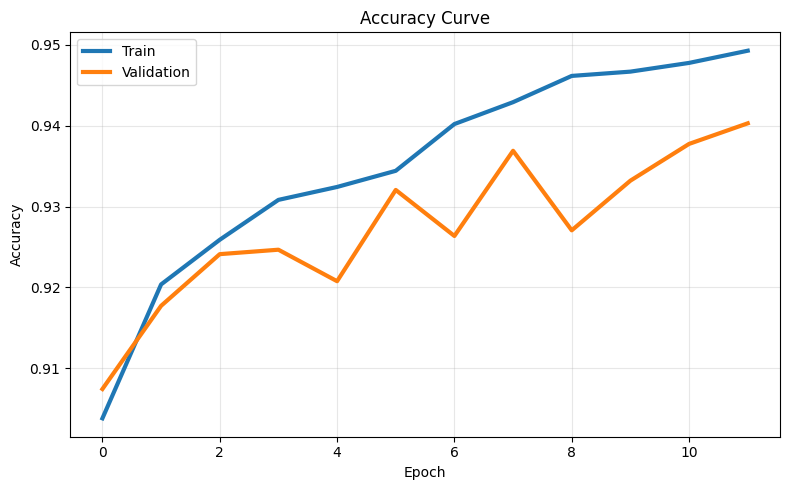

In [36]:
plt.figure(figsize=(8,5))

plt.plot(

    history2["train_acc"],

    linewidth=3,

    label="Train"

)

plt.plot(

    history2["val_acc"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "accuracy_curve.png"

    ),

    dpi=300

)

plt.show()

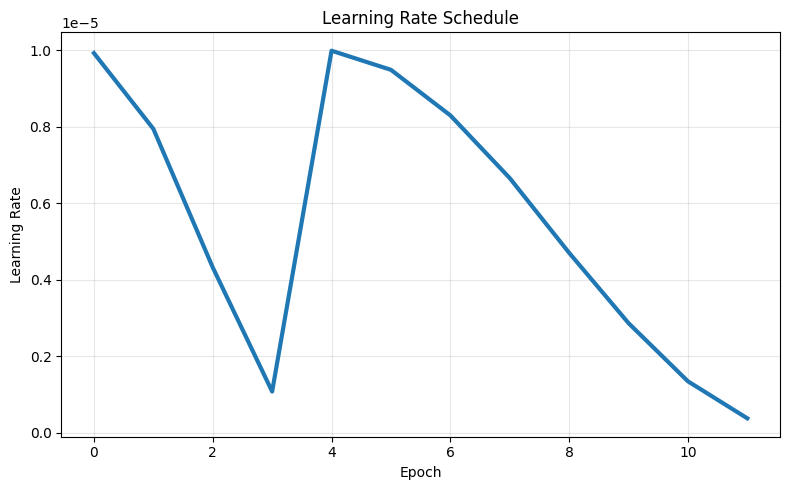

In [37]:
plt.figure(figsize=(8,5))

plt.plot(

    history2["learning_rate"],

    linewidth=3

)

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "learning_rate_curve.png"

    ),

    dpi=300

)

plt.show()

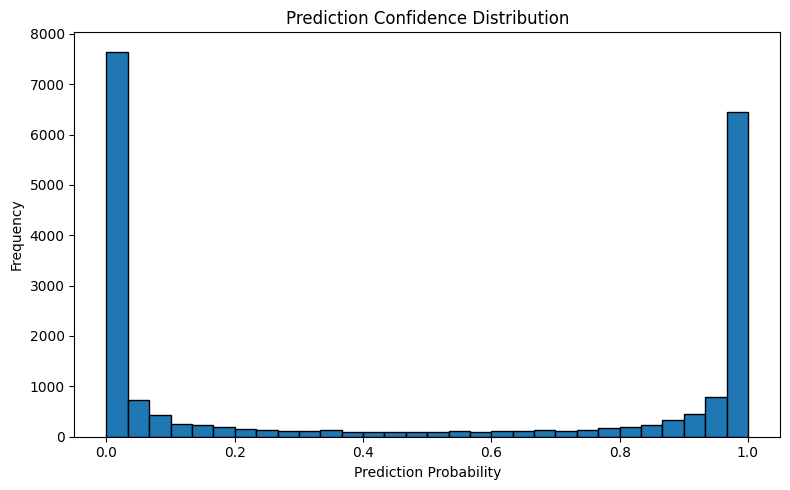

In [38]:
plt.figure(figsize=(8,5))

plt.hist(

    y_prob,

    bins=30,

    edgecolor="black"

)

plt.xlabel("Prediction Probability")

plt.ylabel("Frequency")

plt.title("Prediction Confidence Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "confidence_histogram.png"

    ),

    dpi=300

)

plt.show()

In [39]:
# ==========================================
# Save All Predictions
# ==========================================

prediction_df = pd.DataFrame({

    "Actual": y_true,

    "Predicted": y_pred,

    "Probability": y_prob,

    "Correct": y_true == y_pred

})

prediction_df.to_csv(

    os.path.join(
        RESULTS_DIR,
        "Predictions",
        "predictions.csv"
    ),

    index=False

)

prediction_df.head()

ValueError: Per-column arrays must each be 1-dimensional

In [40]:
# ==========================================
# Original Images
# ==========================================

original_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(len(original_dataset))

20000


In [41]:
misclassified = np.where(y_true != y_pred)[0]

print("Misclassified Images :", len(misclassified))

Misclassified Images : 1194


TypeError: only integer scalar arrays can be converted to a scalar index

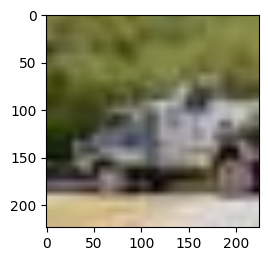

In [42]:
plt.figure(figsize=(16,16))

for i, idx in enumerate(misclassified[:25]):

    image, label = original_dataset[idx]

    image = image.permute(1,2,0).numpy()

    image = image * np.array([0.229,0.224,0.225])

    image += np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(5,5,i+1)

    plt.imshow(image)

    plt.title(
        f"A:{train_dataset.classes[y_true[idx]]}\n"
        f"P:{train_dataset.classes[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Misclassified",

        "misclassified_examples.png"

    ),

    dpi=300

)

plt.show()

In [43]:
correct_idx = np.where(y_true == y_pred)[0]

confidence = y_prob[correct_idx]

sorted_idx = correct_idx[np.argsort(confidence)[::-1]]

In [44]:
plt.figure(figsize=(16,16))

for i, idx in enumerate(sorted_idx[:25]):

    image,_ = original_dataset[idx]

    image = image.permute(1,2,0).numpy()

    image = image * np.array([0.229,0.224,0.225])

    image += np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(5,5,i+1)

    plt.imshow(image)

    plt.title(

        f"{train_dataset.classes[y_pred[idx]]}\n"

        f"{y_prob[idx]:.3f}"

    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Predictions",

        "highest_confidence.png"

    ),

    dpi=300

)

plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

<Figure size 1600x1600 with 0 Axes>

In [45]:
confidence = y_prob[correct_idx]

lowest = correct_idx[np.argsort(confidence)]

In [46]:
plt.figure(figsize=(16,16))

for i, idx in enumerate(lowest[:25]):

    image,_ = original_dataset[idx]

    image = image.permute(1,2,0).numpy()

    image = image * np.array([0.229,0.224,0.225])

    image += np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(5,5,i+1)

    plt.imshow(image)

    plt.title(

        f"{train_dataset.classes[y_pred[idx]]}\n"

        f"{y_prob[idx]:.3f}"

    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Predictions",

        "lowest_confidence.png"

    ),

    dpi=300

)

plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

<Figure size 1600x1600 with 0 Axes>

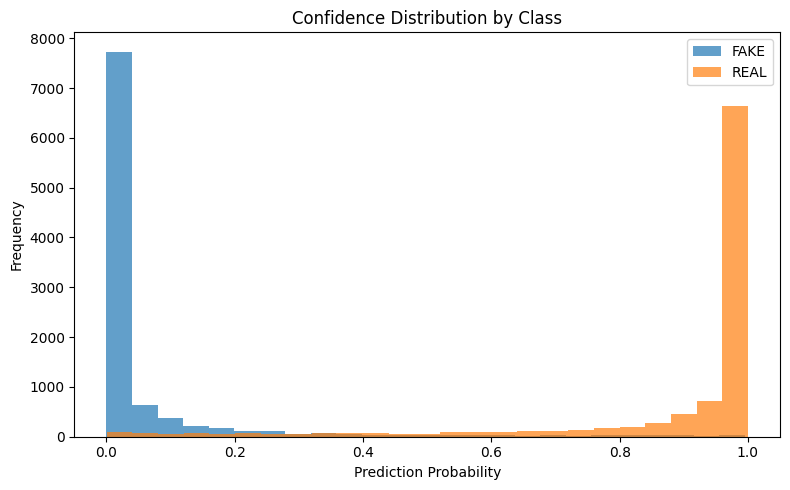

In [47]:
plt.figure(figsize=(8,5))

plt.hist(

    y_prob[y_true==0],

    bins=25,

    alpha=0.7,

    label="FAKE"

)

plt.hist(

    y_prob[y_true==1],

    bins=25,

    alpha=0.7,

    label="REAL"

)

plt.legend()

plt.xlabel("Prediction Probability")

plt.ylabel("Frequency")

plt.title("Confidence Distribution by Class")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_DIR,

        "Plots",

        "class_confidence_distribution.png"

    ),

    dpi=300

)

plt.show()

In [48]:
summary = pd.DataFrame({

    "Statistic":[

        "True Positives",

        "True Negatives",

        "False Positives",

        "False Negatives"

    ],

    "Value":[

        TP,

        TN,

        FP,

        FN

    ]

})

summary

,Statistic,Value
0,True Positives,9168
1,True Negatives,9638
2,False Positives,362
3,False Negatives,832


In [49]:
summary.to_csv(

    os.path.join(

        RESULTS_DIR,

        "Metrics",

        "confusion_matrix_summary.csv"

    ),

    index=False

)

print(summary)

         Statistic  Value
0   True Positives   9168
1   True Negatives   9638
2  False Positives    362
3  False Negatives    832


In [50]:
print("="*60)

print("MODEL :",MODEL_NAME)

print("Train Images :",len(train_dataset))

print("Test Images :",len(test_dataset))

print()

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 :",f1)

print("ROC AUC :",roc_auc)

print("PR AUC :",pr_auc)

print("Specificity :",specificity)

print("Balanced Accuracy :",balanced_acc)

print("MCC :",mcc)

print("Kappa :",kappa)

print()

print("Inference Time :",elapsed,"seconds")

print("="*60)

MODEL : ResNet50
Train Images : 100000
Test Images : 20000

Accuracy : 0.9403
Precision : 0.9620146904512067
Recall : 0.9168
F1 : 0.938863287250384
ROC AUC : 0.98760185
PR AUC : 0.9881804253461015
Specificity : 0.9638
Balanced Accuracy : 0.9402999999999999
MCC : 0.8815742370647085
Kappa : 0.8806

Inference Time : 458.71925354003906 seconds


In [51]:
torch.save(

    {

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "history_stage1":history,

        "history_stage2":stage2_history,

        "metrics":metrics

    },

    os.path.join(

        RESULTS_DIR,

        "Models",

        "Complete_Experiment.pth"

    )

)

print("Entire experiment saved.")

Entire experiment saved.


In [52]:
model_path = os.path.join(
    RESULTS_DIR,
    "Models",
    "best_resnet50_finetuned.pth"
)

size_mb = os.path.getsize(model_path)/(1024*1024)

print(f"Model Size : {size_mb:.2f} MB")

Model Size : 94.25 MB


In [53]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

non_trainable = total_params-trainable_params

parameter_df = pd.DataFrame({

    "Statistic":[

        "Total Parameters",

        "Trainable",

        "Frozen"

    ],

    "Value":[

        total_params,

        trainable_params,

        non_trainable

    ]

})

parameter_df

,Statistic,Value
0,Total Parameters,24623937
1,Trainable,16080641
2,Frozen,8543296


In [54]:
summary = {

    "Architecture":MODEL_NAME,

    "Image Size":IMAGE_SIZE,

    "Batch Size":BATCH_SIZE,

    "Stage1 Epochs":EPOCHS_STAGE1,

    "Stage2 Epochs":EPOCHS_STAGE2,

    "Optimizer":"AdamW",

    "Scheduler":"CosineAnnealingWarmRestarts",

    "Loss":"BCEWithLogitsLoss",

    "Accuracy":accuracy,

    "Precision":precision,

    "Recall":recall,

    "F1":f1,

    "ROC AUC":roc_auc,

    "PR AUC":pr_auc,

    "MCC":mcc,

    "Specificity":specificity,

    "Inference Time(ms)":avg*1000,

    "FPS":fps

}

summary_df = pd.DataFrame(summary,index=[0])

summary_df

NameError: name 'avg' is not defined

In [55]:
# ==========================================
# Zip Entire Results Folder
# ==========================================

import os
import shutil
from IPython.display import FileLink

RESULTS_DIR = "Results"          # Change if your folder name is different
ZIP_NAME = "Results.zip"

# Remove old zip if it exists
if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

# Create zip
shutil.make_archive(
    base_name="Results",
    format="zip",
    root_dir=RESULTS_DIR
)

print(f"✅ ZIP file created: {ZIP_NAME}")

# Show download link (Kaggle/Jupyter)
display(FileLink(ZIP_NAME))

✅ ZIP file created: Results.zip


/kaggle/working/Results.zip